## Simulating MCAR

In [54]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(data.target)

In [55]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [56]:
X.shape

(569, 30)

In [57]:
X.isna().sum().sum()

np.int64(0)

In [58]:
def introduce_missingness(X, missing_rate, random_state=None):

    # 1. Make a copy
    X_missing = X.copy()

    # 2. Calculate number of cells
    no_cells = X.shape[0] * X.shape[1]

    # 3. Calculate number of missing values
    no_missing = int(no_cells * missing_rate)

    # 4. Create random number generator
    rng = np.random.default_rng(random_state)

    # 5. Randomly select unique cells
    indices = rng.choice(no_cells, size=no_missing, replace=False)

    # 6. Convert selected positions to row/column indices
    rows, columns = np.unravel_index(indices, X.shape)

    # 7. Replace those cells with NaN
    X_missing.values[rows, columns] = np.nan


    # 8. Return modified copy
    return X_missing

In [59]:
X_10 = introduce_missingness(
    X,
    0.10,
    random_state=42
)

In [60]:
X_10.isna().sum().sum()

np.int64(1707)

In [61]:
X_10.isna().mean().mean()

np.float64(0.1)

In [62]:
X.isna().sum().sum()

np.int64(0)

In [63]:
X_10 = introduce_missingness(X, 0.10, random_state=42)

X_20 = introduce_missingness(X, 0.20, random_state=42)

X_30 = introduce_missingness(X, 0.30, random_state=42)

X_50 = introduce_missingness(X, 0.50, random_state=42)

In [64]:
print(round(X_10.isna().mean().mean(), 2))
print(round(X_20.isna().mean().mean(), 2))
print(round(X_30.isna().mean().mean(), 2))
print(round(X_50.isna().mean().mean(), 2))

0.1
0.2
0.3
0.5


In [65]:
# Verify that missing data is actually random
X_10.isna().sum()

mean radius                51
mean texture               58
mean perimeter             57
mean area                  51
mean smoothness            59
mean compactness           64
mean concavity             57
mean concave points        48
mean symmetry              58
mean fractal dimension     56
radius error               56
texture error              58
perimeter error            58
area error                 44
smoothness error           53
compactness error          60
concavity error            63
concave points error       51
symmetry error             57
fractal dimension error    56
worst radius               46
worst texture              55
worst perimeter            52
worst area                 59
worst smoothness           58
worst compactness          70
worst concavity            63
worst concave points       65
worst symmetry             70
worst fractal dimension    54
dtype: int64

In [66]:
X_10.isna().sum(axis=1)

0      3
1      0
2      6
3      2
4      4
      ..
564    3
565    2
566    4
567    3
568    5
Length: 569, dtype: int64

In [67]:
# Check total number of missing values
print("10%:", X_10.isna().sum().sum())
print("20%:", X_20.isna().sum().sum())
print("30%:", X_30.isna().sum().sum())
print("50%:", X_50.isna().sum().sum())

10%: 1707
20%: 3414
30%: 5121
50%: 8535


In [68]:
# Calculate percentage misisng
print("10%:", X_10.isna().mean().mean() * 100)
print("20%:", X_20.isna().mean().mean() * 100)
print("30%:", X_30.isna().mean().mean() * 100)
print("50%:", round(X_50.isna().mean().mean() * 100,2))

10%: 10.0
20%: 20.0
30%: 30.0
50%: 50.0


In [69]:
# Make a summary table
missingness_summary = pd.DataFrame({
    "Dataset": ["10%", "20%", "30%", "50%"],
    "Missing Values": [
        X_10.isna().sum().sum(),
        X_20.isna().sum().sum(),
        X_30.isna().sum().sum(),
        X_50.isna().sum().sum()
    ],
    "Percentage Missing": [
        X_10.isna().mean().mean(),
        X_20.isna().mean().mean(),
        X_30.isna().mean().mean(),
        X_50.isna().mean().mean()
    ]
})
missingness_summary["Percentage Missing"] *= 100
missingness_summary

,Dataset,Missing Values,Percentage Missing
0,10%,1707,10.0
1,20%,3414,20.0
2,30%,5121,30.0
3,50%,8535,50.0


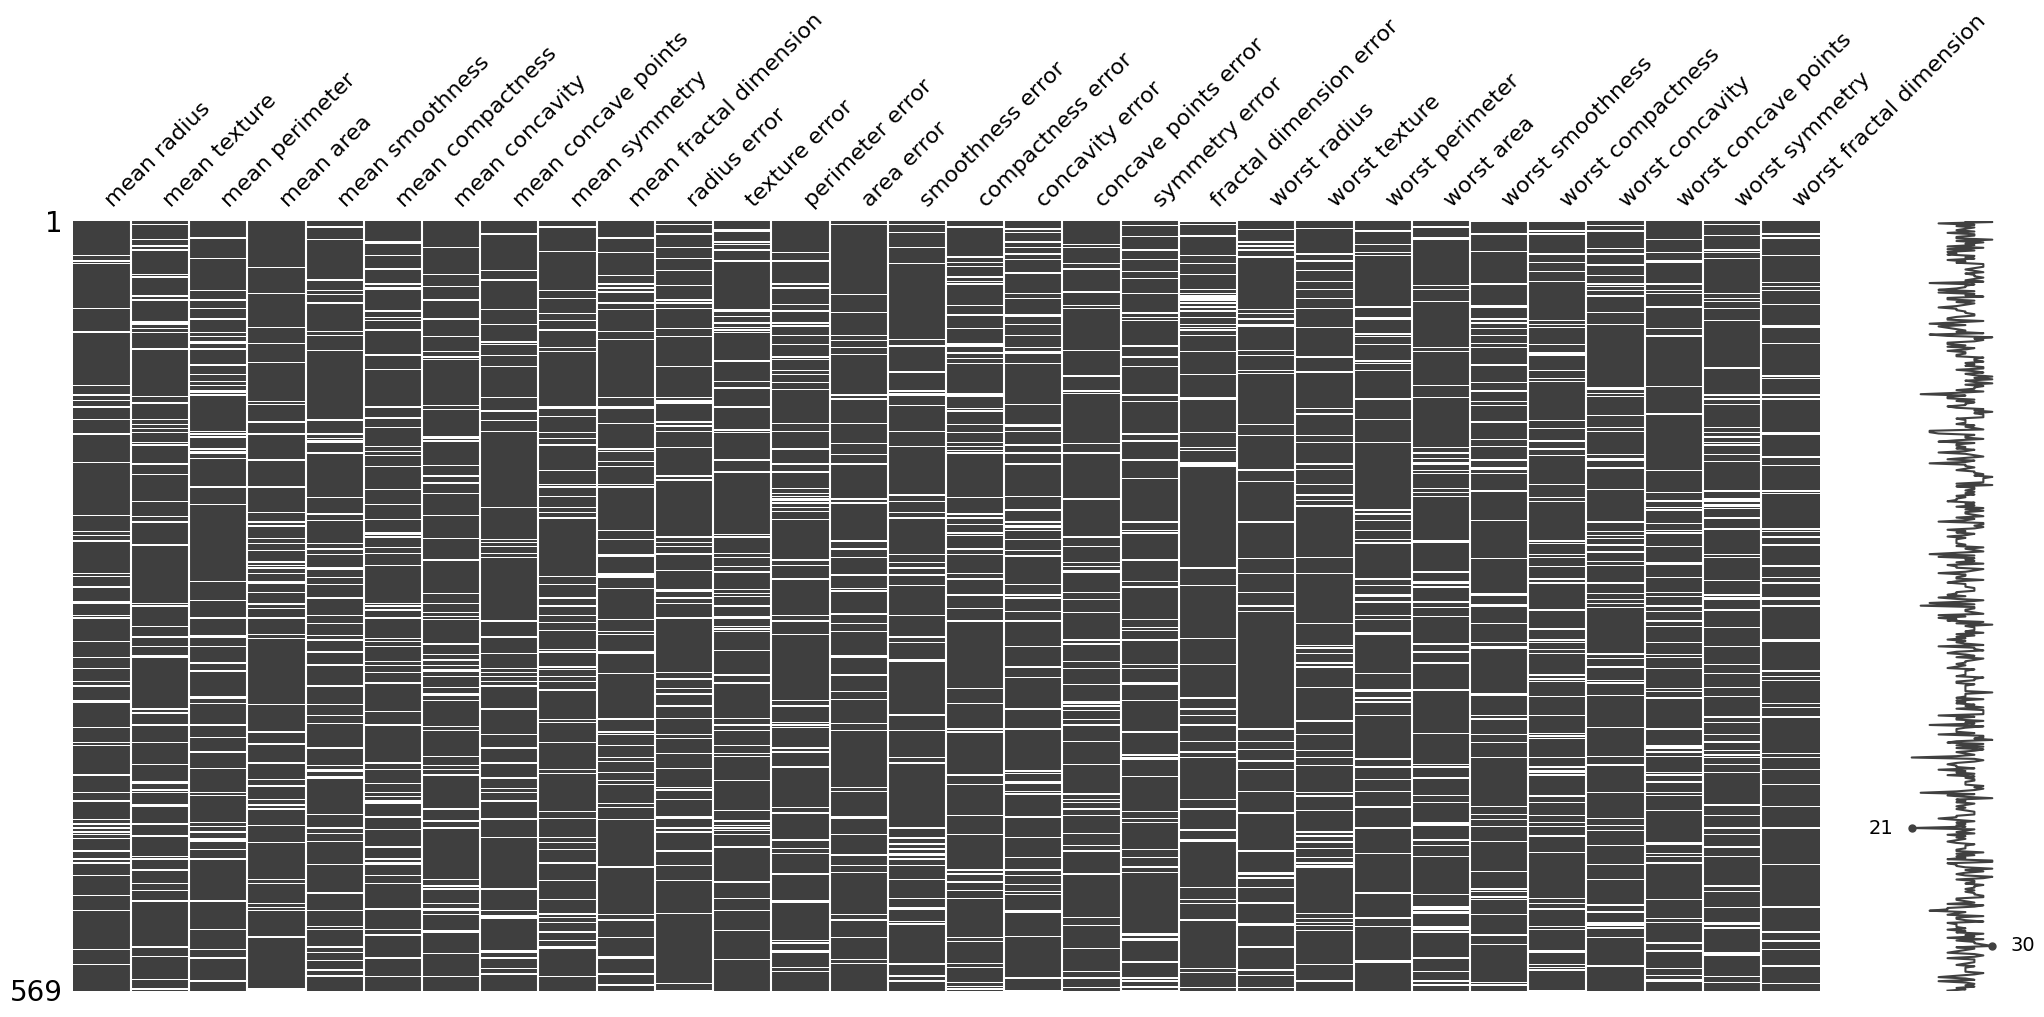

In [70]:
# Visualise missingness
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(X_10)

plt.show()

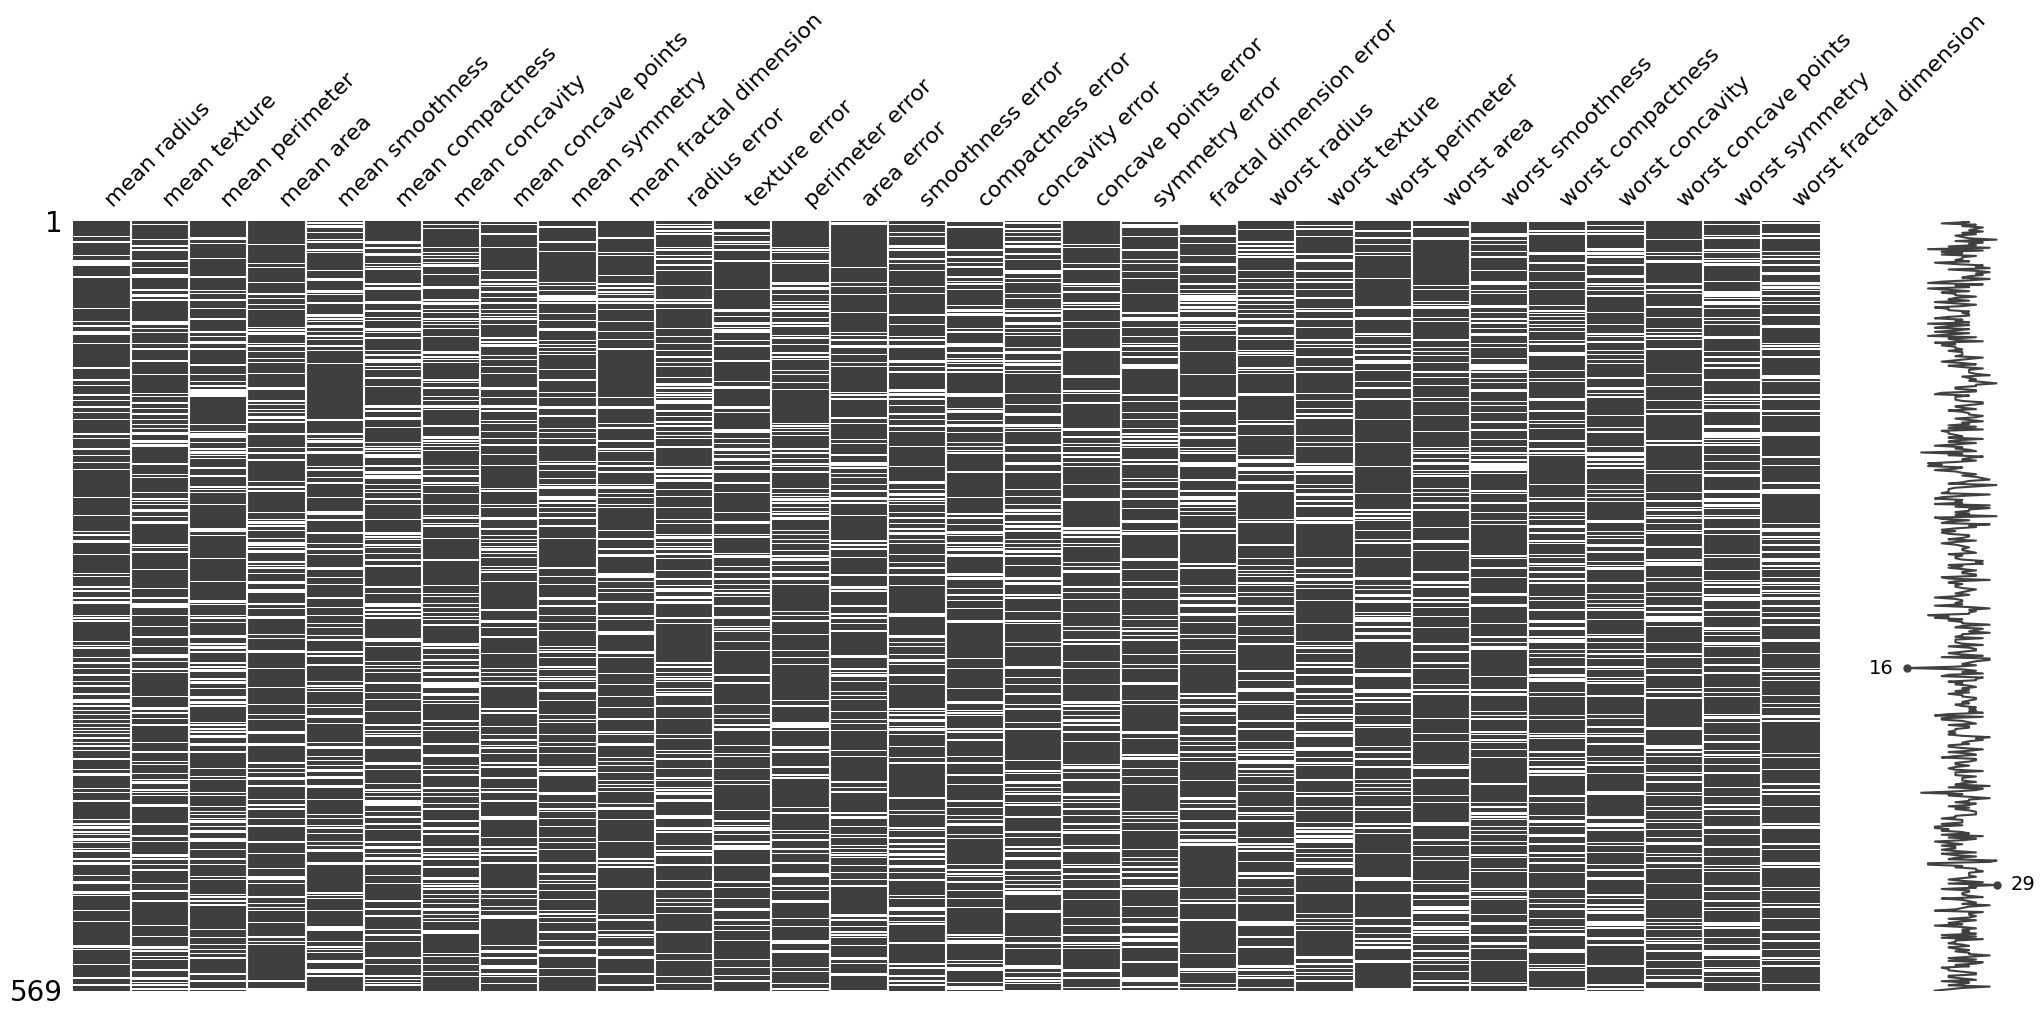

In [71]:
msno.matrix(X_20)
plt.show()

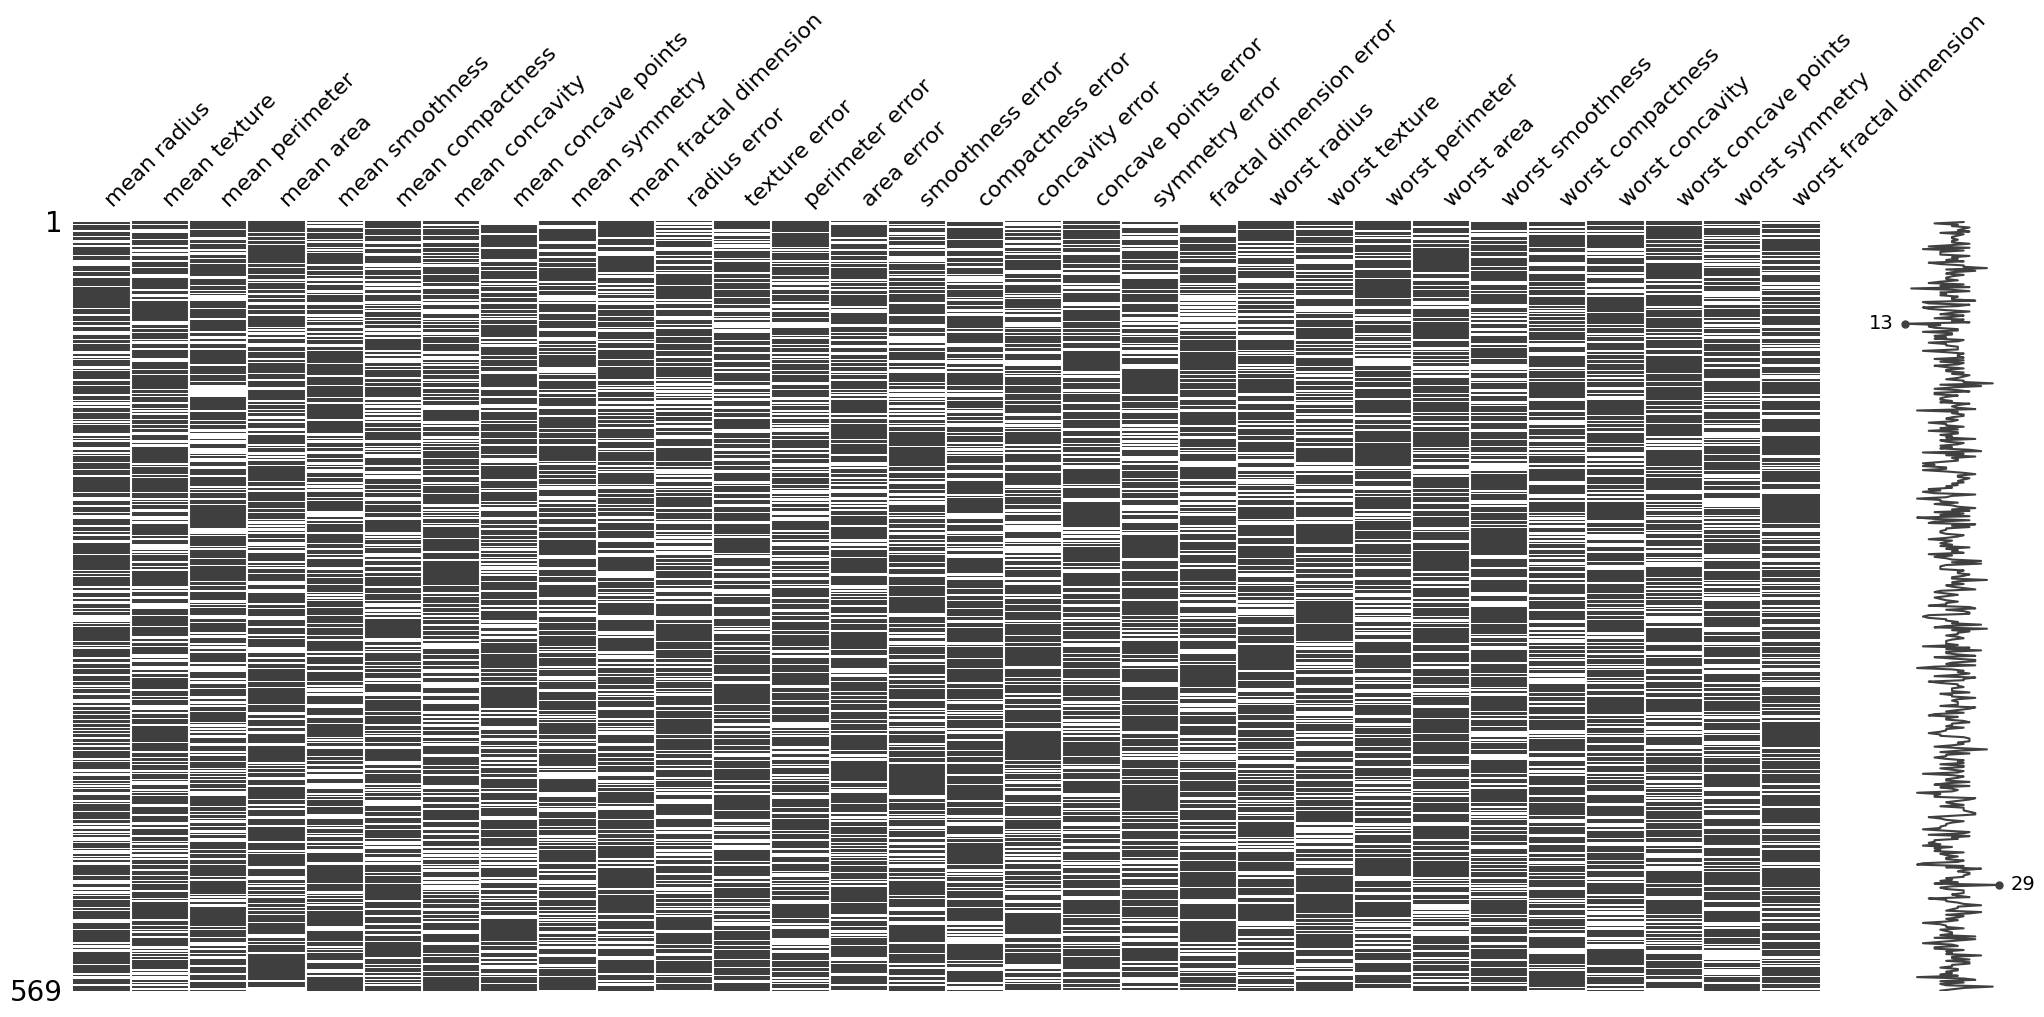

In [72]:
msno.matrix(X_30)
plt.show()

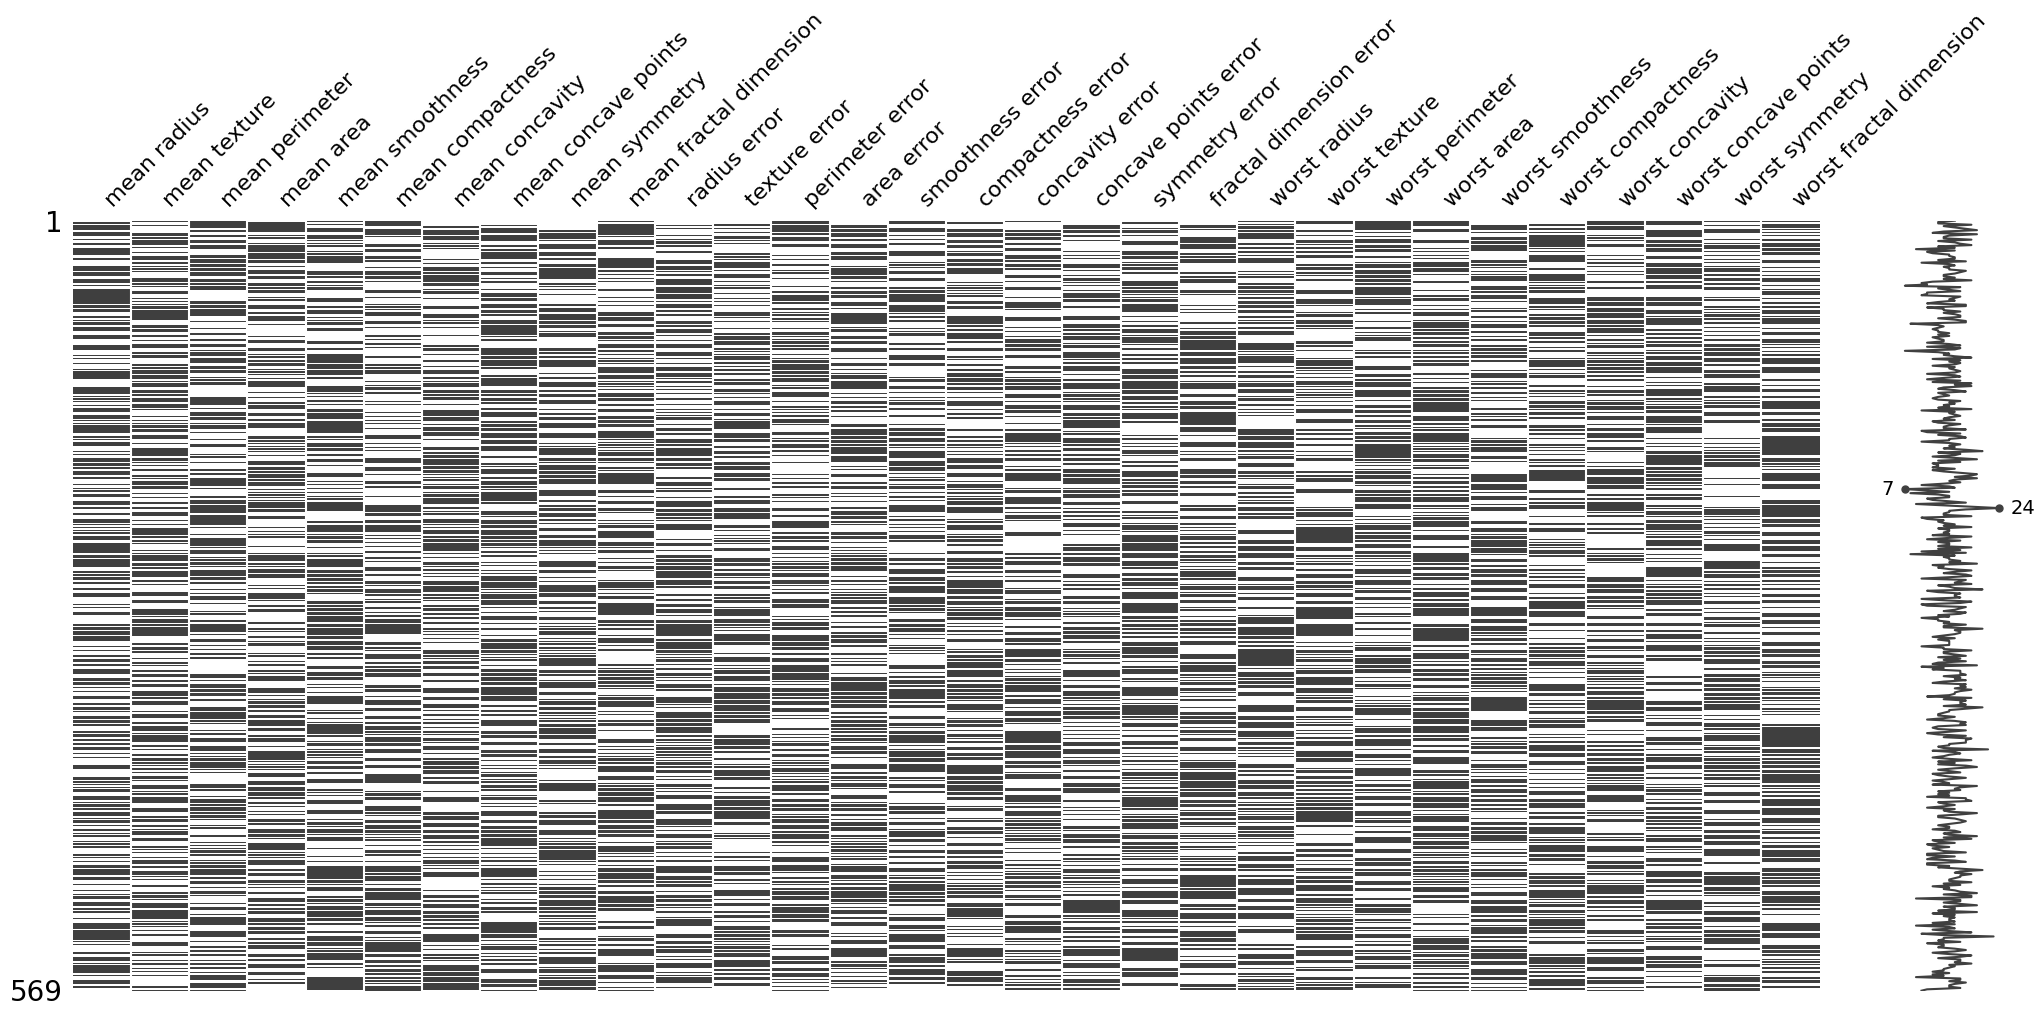

In [73]:
msno.matrix(X_50)
plt.show()

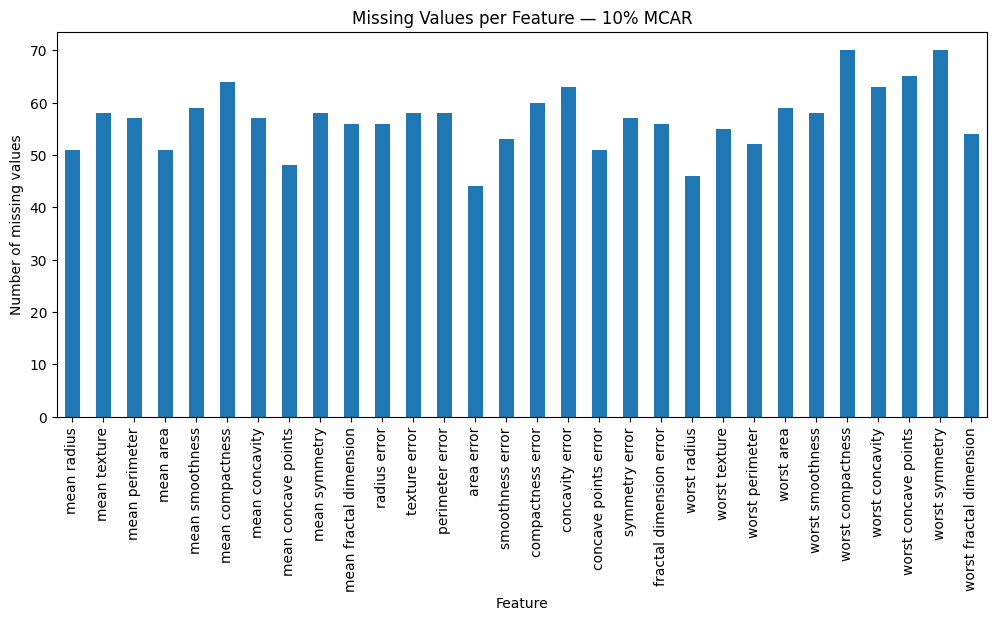

In [74]:
X_10.isna().sum().plot(kind="bar", figsize=(12, 5))

plt.ylabel("Number of missing values")
plt.xlabel("Feature")
plt.title("Missing Values per Feature — 10% MCAR")

plt.show()

### Observations
- The missingness function successfully introduced the requested levels of missing data (10%, 20%, 30%, and 50%).
- The proportion of missing values in each dataset was approximately equal to the specified missingness rate.
- The original dataset remained unchanged, with no missing values.
- Missing values were distributed randomly across rows and features rather than being concentrated in particular variables.
- This provides a simulation of MCAR missingness, where the probability of a value being missing does not depend on the observed data.
- The visualisation shows a scattered pattern of missing values, consistent with the intended MCAR mechanism.

## Complete-case analysis experiment

In [86]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_10 = introduce_missingness(
    X_train,
    0.10,
    random_state=42
)

X_train_10_complete = X_train_10.dropna()

In [87]:
print(X_train.shape)
print(X_train_10_complete.shape)

(455, 30)
(18, 30)


In [88]:
y_train_10_complete = y_train.loc[X_train_10_complete.index]

In [89]:
print(X_train_10_complete.shape)
print(y_train_10_complete.shape)

(18, 30)
(18,)


In [90]:
# Verify X and y are aligned
print(X_train_10_complete.index.equals(y_train_10_complete.index))

True


In [91]:
# Check that there are no NaNs left
print(X_train_10_complete.isna().sum().sum())

0


In [105]:
# Evaluation function
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    auc = roc_auc_score(y_test, probabilities)

    return {
        "accuracy": accuracy,
        "f1": f1,
        "auc": auc
    }

In [93]:
# Logistic Regression
logistic_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)

logistic_model.fit(X_train_10_complete, y_train_10_complete)

predictions = logistic_model.predict(X_test)

evaluate_model(
    logistic_model,
    X_test,
    y_test
)

0.9035087719298246

In [94]:
# Random Forest
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train_10_complete,
    y_train_10_complete
)

evaluate_model(
    rf,
    X_test,
    y_test
)

0.8771929824561403

In [95]:
results = []

X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

for missing_rate in [0.10, 0.20, 0.30, 0.50]:

    # introduce MCAR
    X_train_missing = introduce_missingness(
        X_train,
        missing_rate,
        random_state=42
    )

    # remove incomplete rows
    X_train_missing_complete = X_train_missing.dropna()

    # align y
    y_train_missing_complete = y_train.loc[X_train_missing_complete.index]

    print("Missing rate:", missing_rate)
    print("Rows remaining:", X_train_missing_complete.shape[0])
    print("Classes remaining:")
    print(y_train_missing_complete.value_counts())

    # train Logistic Regression
    logistic_model = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000)
    )

    logistic_model.fit(X_train_missing_complete, y_train_missing_complete)

    predictions = logistic_model.predict(X_test)

    # evaluate
    evaluate_model(
            logistic_model,
            X_test,
            y_test
        )

    # train Random Forest
    rf = RandomForestClassifier(
        random_state=42
    )

    rf.fit(
        X_train_missing_complete,
        y_train_missing_complete
    )

    # evaluate
    evaluate_model(
            rf,
            X_test,
            y_test
        )

    # save number of rows remaining
    rows_remain = X_train_missing_complete.shape[0]

    results.append({
        "missing_rate": missing_rate,
        "rows_remaining": rows_remain
    })

print(results)

Missing rate: 0.1
Rows remaining: 18
Classes remaining:
1    13
0     5
Name: count, dtype: int64
Missing rate: 0.2
Rows remaining: 1
Classes remaining:
1    1
Name: count, dtype: int64


ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(1)

Observation: With 30 features, complete-case analysis results in a substantial loss of training observations even at relatively low MCAR levels. At 10% missingness, only 18 of the 455 training observations remained complete, while at 20% missingness only 1 observation remained. This demonstrates that complete-case analysis can become highly inefficient as the number of features and missingness rate increase.

This occurs because, for a row to survive complete-case analysis, all 30 features must be observed.

At 10% missingness:

$P(\text{row complete}) = (1 - 0.10)^{30} = 0.9^{30} \approx 0.0424$

Therefore:

$455 \times 0.0424 \approx 19$

which is close to the observed 18 complete rows.

At 20% missingness:

$P(\text{row complete}) = (1 - 0.20)^{30} = 0.8^{30} \approx 0.00124$  

Therefore:

$455 \times 0.00124 \approx 0.56$

which is consistent with observing 1 complete row.


## Complete-case Experiment

In [123]:
# Experiment
results = []

X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

missing_rates = [0, 0.10, 0.20, 0.30, 0.50]

for rate in missing_rates:

    if rate == 0:
        X_train_missing = X_train.copy()
    else:
        X_train_missing = introduce_missingness(
            X_train,
            rate,
            random_state=42
        )

    # Remove incomplete rows
    X_train_missing_complete = X_train_missing.dropna()

    # Find corresponding y values
    y_train_missing_complete = y_train.loc[X_train_missing_complete.index]

    # Count remaining rows
    rows_remaining = len(X_train_missing_complete)


    # If enough rows:
    if rows_remaining >= 10 and y_train_missing_complete.nunique() >= 2:
        # train Logistic Regression
        logistic_model = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=5000)
        )
    
        logistic_model.fit(X_train_missing_complete, y_train_missing_complete)
        
        # evaluate
        metrics = evaluate_model(
                logistic_model,
                X_test,
                y_test
            )

        results.append({
            "missingness": rate,
            "model": "Logistic Regression",
            "accuracy": metrics["accuracy"],
            "f1": metrics["f1"],
            "auc": metrics["auc"],
            "rows_remaining": rows_remaining
        })
        
        # train Random Forest
        rf = RandomForestClassifier(
            random_state=42
        )
    
        rf.fit(
            X_train_missing_complete,
            y_train_missing_complete
        )
    
        # evaluate
        metrics = evaluate_model(
            rf,
            X_test,
            y_test
        )
        results.append({
            "missingness": rate,
            "model": "Random Forest",
            "accuracy": metrics["accuracy"],
            "f1": metrics["f1"],
            "auc": metrics["auc"],
            "rows_remaining": rows_remaining
        })

    else:
        results.append({
            "missingness": rate,
            "model": "Logistic Regression",
            "accuracy": np.nan,
            "f1": np.nan,
            "auc": np.nan,
            "rows_remaining": rows_remaining
        })

        results.append({
            "missingness": rate,
            "model": "Random Forest",
            "accuracy": np.nan,
            "f1": np.nan,
            "auc": np.nan,
            "rows_remaining": rows_remaining
        })

results_df = pd.DataFrame(results)

results_df

,missingness,model,accuracy,f1,auc,rows_remaining
0,0.0,Logistic Regression,0.982456,0.986111,0.995370,455
1,0.0,Random Forest,0.956140,0.965517,0.993717,455
2,0.1,Logistic Regression,0.903509,0.929032,0.982804,18
3,0.1,Random Forest,0.877193,0.911392,0.972884,18
4,0.2,Logistic Regression,NaN,NaN,NaN,1
5,0.2,Random Forest,NaN,NaN,NaN,1
6,0.3,Logistic Regression,NaN,NaN,NaN,0
7,0.3,Random Forest,NaN,NaN,NaN,0
8,0.5,Logistic Regression,NaN,NaN,NaN,0
9,0.5,Random Forest,NaN,NaN,NaN,0


In [124]:
results_df.to_csv(
    "../results/mcar_complete_case_results.csv",
    index=False
)

### Accuracy Vs Missingness plot

In [125]:
logistic_results = results_df[
    results_df["model"] == "Logistic Regression"
]

rf_results = results_df[
    results_df["model"] == "Random Forest"
]

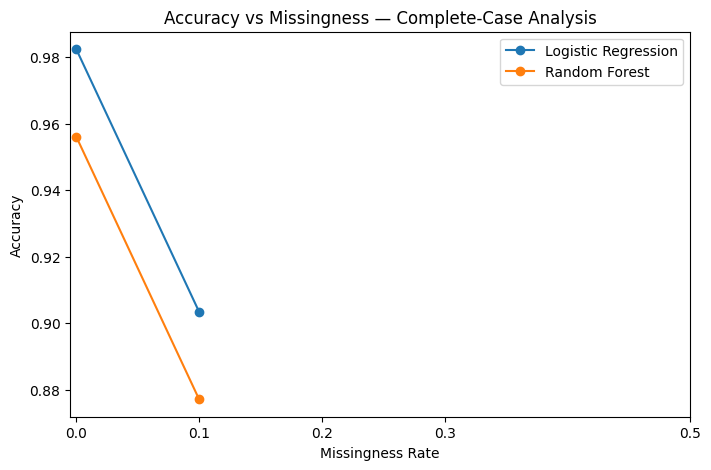

In [126]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    logistic_results["missingness"],
    logistic_results["accuracy"],
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    rf_results["missingness"],
    rf_results["accuracy"],
    marker="o",
    label="Random Forest"
)

plt.xlabel("Missingness Rate")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Missingness — Complete-Case Analysis")

plt.xticks([0, 0.10, 0.20, 0.30, 0.50])

plt.legend()

plt.show()

### Analysis

Complete-case analysis resulted in a rapid reduction in the number of available training observations as the MCAR rate increased. At 10% missingness, only 18 of the 455 training observations remained complete, while at 20% only one observation remained.

The models could therefore only be meaningfully evaluated at the lower missingness levels. This demonstrates that complete-case analysis can become impractical even when the proportion of missing individual feature values is relatively modest.

The accuracy results should be interpreted alongside the number of observations remaining, rather than considered in isolation.

### Repeat experiment with multiple seeds

In [127]:
# Repeated MCAR experiments

results = []

# -----------------------------
# 1. Train/test split ONCE
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# 2. 0% missingness baseline
# -----------------------------

X_train_complete = X_train.copy()
y_train_complete = y_train.copy()

rows_remaining = len(X_train_complete)

# Logistic Regression
logistic_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)

logistic_model.fit(
    X_train_complete,
    y_train_complete
)

metrics = evaluate_model(
    logistic_model,
    X_test,
    y_test
)

results.append({
    "missingness": 0,
    "seed": None,
    "model": "Logistic Regression",
    "accuracy": metrics["accuracy"],
    "f1": metrics["f1"],
    "auc": metrics["auc"],
    "rows_remaining": rows_remaining
})

# Random Forest
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train_complete,
    y_train_complete
)

metrics = evaluate_model(
    rf,
    X_test,
    y_test
)

results.append({
    "missingness": 0,
    "seed": None,
    "model": "Random Forest",
    "accuracy": metrics["accuracy"],
    "f1": metrics["f1"],
    "auc": metrics["auc"],
    "rows_remaining": rows_remaining
})


# -----------------------------
# 3. Repeated MCAR experiments
# -----------------------------

missing_rates = [0.10, 0.20, 0.30, 0.50]
seeds = [1, 2, 3, 4, 5]

for rate in missing_rates:

    for seed in seeds:

        # Introduce MCAR
        X_train_missing = introduce_missingness(
            X_train,
            rate,
            random_state=seed
        )

        # Complete-case analysis
        X_train_missing_complete = X_train_missing.dropna()

        # Align y
        y_train_missing_complete = y_train.loc[
            X_train_missing_complete.index
        ]

        # Count remaining rows
        rows_remaining = len(
            X_train_missing_complete
        )

        # Check whether there are enough observations
        # and at least two classes
        if (
            rows_remaining >= 10
            and y_train_missing_complete.nunique() >= 2
        ):

            # -----------------------------
            # Logistic Regression
            # -----------------------------

            logistic_model = make_pipeline(
                StandardScaler(),
                LogisticRegression(max_iter=5000)
            )

            logistic_model.fit(
                X_train_missing_complete,
                y_train_missing_complete
            )

            metrics = evaluate_model(
                logistic_model,
                X_test,
                y_test
            )

            results.append({
                "missingness": rate,
                "seed": seed,
                "model": "Logistic Regression",
                "accuracy": metrics["accuracy"],
                "f1": metrics["f1"],
                "auc": metrics["auc"],
                "rows_remaining": rows_remaining
            })

            # -----------------------------
            # Random Forest
            # -----------------------------

            rf = RandomForestClassifier(
                random_state=seed
            )

            rf.fit(
                X_train_missing_complete,
                y_train_missing_complete
            )

            metrics = evaluate_model(
                rf,
                X_test,
                y_test
            )

            results.append({
                "missingness": rate,
                "seed": seed,
                "model": "Random Forest",
                "accuracy": metrics["accuracy"],
                "f1": metrics["f1"],
                "auc": metrics["auc"],
                "rows_remaining": rows_remaining
            })

        else:

            # Model cannot be trained
            results.append({
                "missingness": rate,
                "seed": seed,
                "model": "Logistic Regression",
                "accuracy": np.nan,
                "f1": np.nan,
                "auc": np.nan,
                "rows_remaining": rows_remaining
            })

            results.append({
                "missingness": rate,
                "seed": seed,
                "model": "Random Forest",
                "accuracy": np.nan,
                "f1": np.nan,
                "auc": np.nan,
                "rows_remaining": rows_remaining
            })

In [128]:
results_df = pd.DataFrame(results)

results_df

,missingness,seed,model,accuracy,f1,auc,rows_remaining
0,0.0,NaN,Logistic Regression,0.982456,0.986111,0.995370,455
1,0.0,NaN,Random Forest,0.956140,0.965517,0.993717,455
2,0.1,1.0,Logistic Regression,0.938596,0.952381,0.986442,23
3,0.1,1.0,Random Forest,0.921053,0.939597,0.988757,23
4,0.1,2.0,Logistic Regression,0.929825,0.947368,0.986442,14
5,0.1,2.0,Random Forest,0.912281,0.933333,0.965443,14
6,0.1,3.0,Logistic Regression,0.868421,0.883721,0.987103,24
7,0.1,3.0,Random Forest,0.885965,0.902256,0.985780,24
8,0.1,4.0,Logistic Regression,0.903509,0.921986,0.956680,16
9,0.1,4.0,Random Forest,0.938596,0.951724,0.980820,16


In [129]:
summary = (
    results_df
    .groupby(["missingness", "model"])
    .agg(
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),
        mean_f1=("f1", "mean"),
        std_f1=("f1", "std"),
        mean_auc=("auc", "mean"),
        std_auc=("auc", "std"),
        mean_rows=("rows_remaining", "mean")
    )
    .reset_index()
)

In [130]:
summary

,missingness,model,mean_accuracy,std_accuracy,mean_f1,std_f1,mean_auc,std_auc,mean_rows
0,0.0,Logistic Regression,0.982456,NaN,0.986111,NaN,0.995370,NaN,455.0
1,0.0,Random Forest,0.956140,NaN,0.965517,NaN,0.993717,NaN,455.0
2,0.1,Logistic Regression,0.914035,0.028694,0.929497,0.028071,0.981878,0.014331,19.6
3,0.1,Random Forest,0.917544,0.020194,0.933954,0.018921,0.981283,0.009300,19.6
4,0.2,Logistic Regression,NaN,NaN,NaN,NaN,NaN,NaN,0.0
5,0.2,Random Forest,NaN,NaN,NaN,NaN,NaN,NaN,0.0
6,0.3,Logistic Regression,NaN,NaN,NaN,NaN,NaN,NaN,0.0
7,0.3,Random Forest,NaN,NaN,NaN,NaN,NaN,NaN,0.0
8,0.5,Logistic Regression,NaN,NaN,NaN,NaN,NaN,NaN,0.0
9,0.5,Random Forest,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [131]:
logistic_summary = summary[
    summary["model"] == "Logistic Regression"
]

rf_summary = summary[
    summary["model"] == "Random Forest"
]

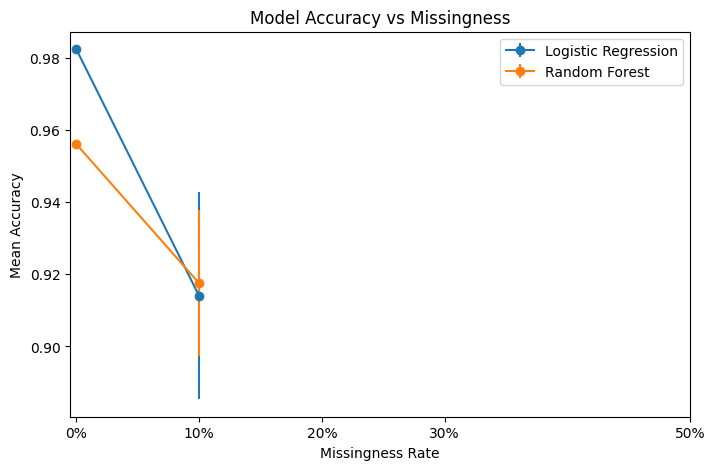

In [132]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.errorbar(
    logistic_summary["missingness"],
    logistic_summary["mean_accuracy"],
    yerr=logistic_summary["std_accuracy"],
    marker="o",
    label="Logistic Regression"
)

plt.errorbar(
    rf_summary["missingness"],
    rf_summary["mean_accuracy"],
    yerr=rf_summary["std_accuracy"],
    marker="o",
    label="Random Forest"
)

plt.xlabel("Missingness Rate")
plt.ylabel("Mean Accuracy")
plt.title("Model Accuracy vs Missingness")
plt.xticks(
    [0, 0.1, 0.2, 0.3, 0.5],
    ["0%", "10%", "20%", "30%", "50%"]
)

plt.legend()
plt.show()

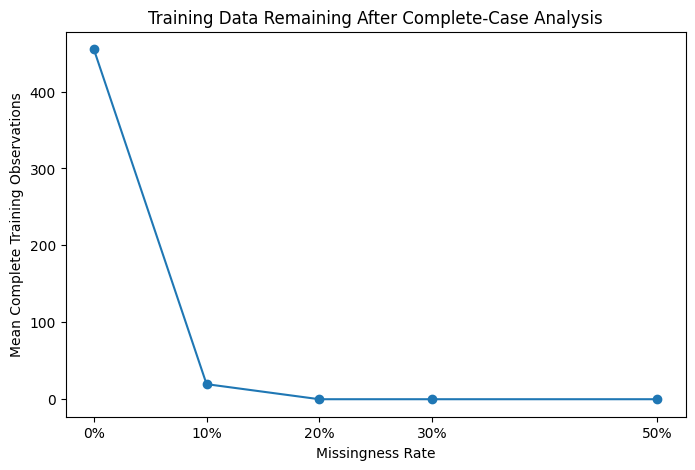

In [133]:
plt.figure(figsize=(8, 5))

plt.plot(
    summary[summary["model"] == "Logistic Regression"]["missingness"],
    summary[summary["model"] == "Logistic Regression"]["mean_rows"],
    marker="o"
)

plt.xlabel("Missingness Rate")
plt.ylabel("Mean Complete Training Observations")
plt.title("Training Data Remaining After Complete-Case Analysis")

plt.xticks(
    [0, 0.1, 0.2, 0.3, 0.5],
    ["0%", "10%", "20%", "30%", "50%"]
)

plt.show()

### Conclusion

The MCAR experiment demonstrates that complete-case analysis can lead to substantial data loss as the missingness rate increases. This effect is particularly severe for datasets with many features, since a single missing value causes an entire observation to be discarded.

At 10% MCAR, only 18 of the 455 training observations remained complete, while at 20% only one observation remained. Consequently, complete-case analysis became impractical at relatively low missingness rates.

The results demonstrate that simply removing incomplete observations is not an effective strategy for handling missing data in this dataset. This motivates the use of imputation methods, which aim to retain observations while estimating their missing values.

The next stage of the project will therefore investigate whether different imputation methods can preserve model performance while avoiding the severe loss of training data observed with complete-case analysis.